Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2956 entries, 0 to 2955
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2956 non-null   object 
 1   Open       2956 non-null   float64
 2   High       2956 non-null   float64
 3   Low        2956 non-null   float64
 4   Close      2956 non-null   float64
 5   Adj Close  2956 non-null   float64
 6   Volume     2956 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 161.8+ KB
None

Missing values:
 Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


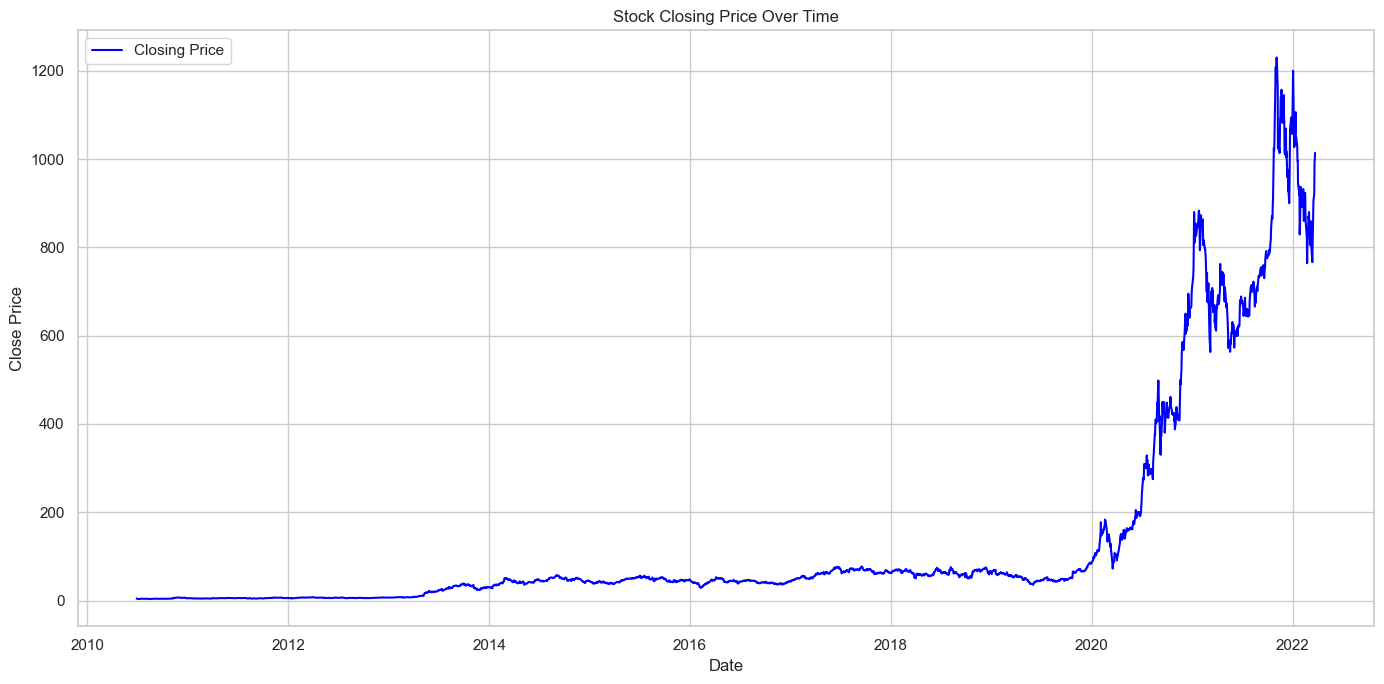

Epoch 1, Train Loss: 81584.5220, Val Loss: 80739.6679
Epoch 2, Train Loss: 76694.7115, Val Loss: 74752.4054
Epoch 3, Train Loss: 70307.5265, Val Loss: 67084.6870
Epoch 4, Train Loss: 61699.4934, Val Loss: 57955.8389
Epoch 5, Train Loss: 52252.7483, Val Loss: 48210.4847
Epoch 6, Train Loss: 42495.3855, Val Loss: 38235.5645
Epoch 7, Train Loss: 32826.0472, Val Loss: 29392.1497
Epoch 8, Train Loss: 24656.8112, Val Loss: 21959.3545
Epoch 9, Train Loss: 18125.1039, Val Loss: 16245.9031
Epoch 10, Train Loss: 13086.0138, Val Loss: 11755.8301
Epoch 11, Train Loss: 9303.5702, Val Loss: 8329.6128
Epoch 12, Train Loss: 6614.6637, Val Loss: 6030.1403
Epoch 13, Train Loss: 4906.1646, Val Loss: 4607.9244
Epoch 14, Train Loss: 4085.3639, Val Loss: 3826.7146
Epoch 15, Train Loss: 3189.1679, Val Loss: 3088.1895
Epoch 16, Train Loss: 2599.0270, Val Loss: 2410.3946
Epoch 17, Train Loss: 2335.0181, Val Loss: 1923.8063
Epoch 18, Train Loss: 1784.3724, Val Loss: 1987.7021
Epoch 19, Train Loss: 1451.6253, Va

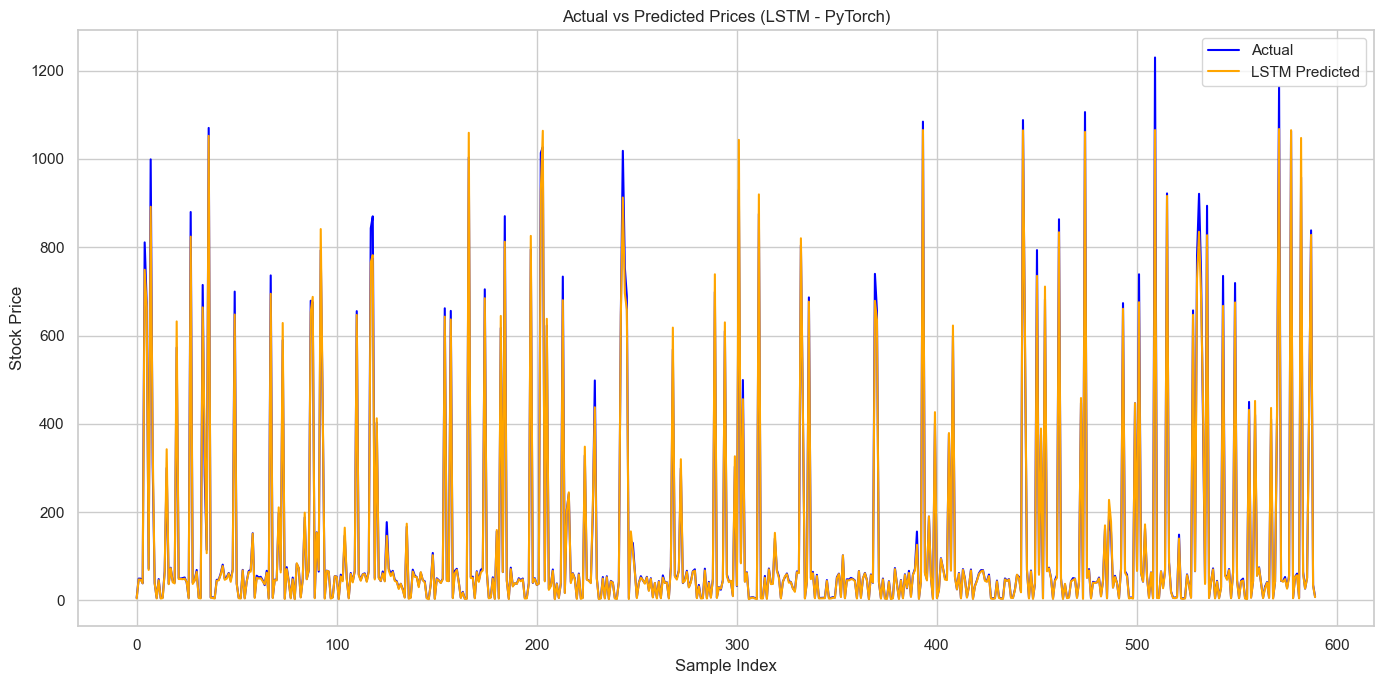

Random Forest - RMSE: 9.8049, MAE: 3.8761, R2: 0.9984


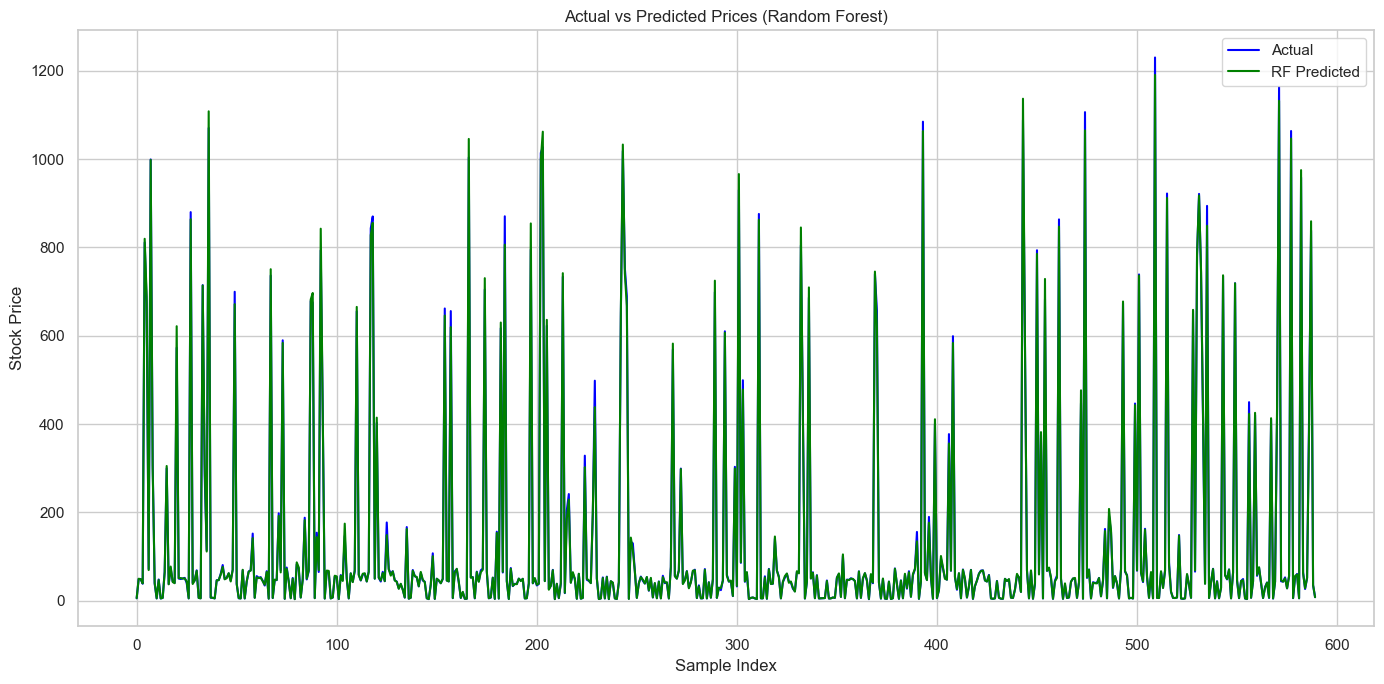

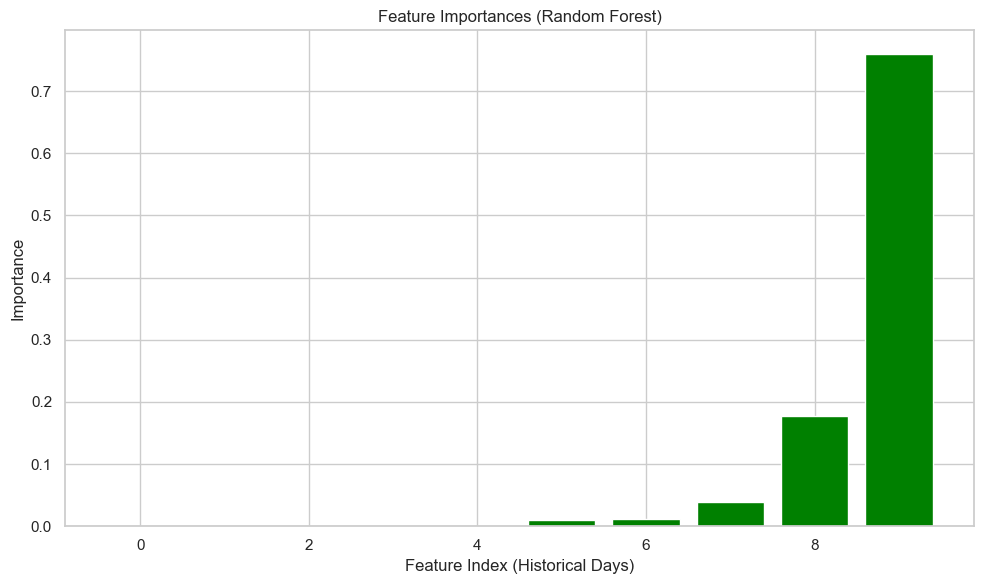

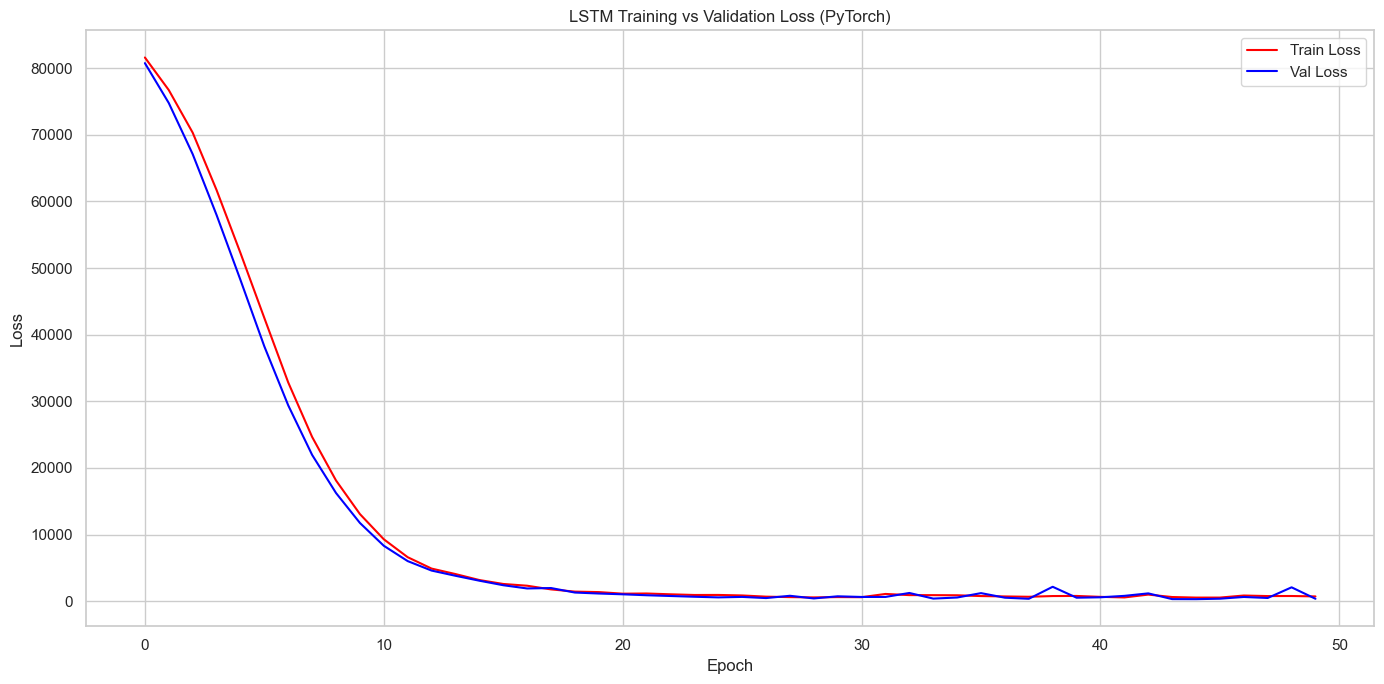


Model Comparison:
LSTM (PyTorch) - RMSE: 19.2802, MAE: 7.5391, R2: 0.9939
RF            - RMSE: 9.8049, MAE: 3.8761, R2: 0.9984


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

sns.set_theme(style="whitegrid")

# Load and prepare data
data = pd.read_csv('TSLA.csv')
print("Dataset Info:")
print(data.info())
print("\nMissing values:\n", data.isnull().sum())

if 'Date' in data.columns:
    data['Date'] = pd.to_datetime(data['Date'])
    data.set_index('Date', inplace=True)

# Plot closing price
plt.figure(figsize=(14, 7))
plt.plot(data['Close'], label='Closing Price', color='blue')
plt.title('Stock Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.tight_layout()
plt.show()

# Drop missing values
data = data.dropna()

# Feature engineering
window_size = 10
features = []
targets = []
for i in range(window_size, len(data)):
    features.append(data['Close'].iloc[i - window_size:i].values)
    targets.append(data['Close'].iloc[i])
features = np.array(features)
targets = np.array(targets)

# Split data
X_train, X_test, y_train, y_test = train_test_split(features, targets, test_size=0.2, random_state=42)

# Reshape for LSTM
X_train_lstm = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test_lstm = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train_lstm, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_lstm, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Define LSTM model
class LSTMModel(nn.Module):
    def __init__(self):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=50, num_layers=2, batch_first=True, dropout=0.2)
        self.fc1 = nn.Linear(50, 25)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(25, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.relu(self.fc1(out))
        return self.fc2(out)

# Train the model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LSTMModel().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_losses, val_losses = [], []

for epoch in range(50):
    model.train()
    epoch_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs.squeeze(), y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    train_losses.append(epoch_loss / len(train_loader))

    # Validation loss
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for X_val, y_val in test_loader:
            X_val, y_val = X_val.to(device), y_val.to(device)
            val_pred = model(X_val)
            val_loss += criterion(val_pred.squeeze(), y_val).item()
    val_losses.append(val_loss / len(test_loader))
    print(f"Epoch {epoch+1}, Train Loss: {train_losses[-1]:.4f}, Val Loss: {val_losses[-1]:.4f}")

# Evaluation
y_pred_lstm = model(X_test_tensor.to(device)).detach().cpu().numpy().squeeze()
rmse_lstm = np.sqrt(mean_squared_error(y_test, y_pred_lstm))
mae_lstm = mean_absolute_error(y_test, y_pred_lstm)
r2_lstm = r2_score(y_test, y_pred_lstm)
print(f'LSTM (PyTorch) - RMSE: {rmse_lstm:.4f}, MAE: {mae_lstm:.4f}, R2: {r2_lstm:.4f}')

# Plot predictions
plt.figure(figsize=(14, 7))
plt.plot(y_test, label='Actual', color='blue')
plt.plot(y_pred_lstm, label='LSTM Predicted', color='orange')
plt.title('Actual vs Predicted Prices (LSTM - PyTorch)')
plt.xlabel('Sample Index')
plt.ylabel('Stock Price')
plt.legend()
plt.tight_layout()
plt.show()

# Random Forest
scaler = StandardScaler()
X_train_rf = scaler.fit_transform(X_train)
X_test_rf = scaler.transform(X_test)
model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf.fit(X_train_rf, y_train)

# Evaluate RF
y_pred_rf = model_rf.predict(X_test_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)
print(f'Random Forest - RMSE: {rmse_rf:.4f}, MAE: {mae_rf:.4f}, R2: {r2_rf:.4f}')

# Plot RF results
plt.figure(figsize=(14, 7))
plt.plot(y_test, label='Actual', color='blue')
plt.plot(y_pred_rf, label='RF Predicted', color='green')
plt.title('Actual vs Predicted Prices (Random Forest)')
plt.xlabel('Sample Index')
plt.ylabel('Stock Price')
plt.legend()
plt.tight_layout()
plt.show()

# Feature Importance
importances = model_rf.feature_importances_
plt.figure(figsize=(10, 6))
plt.bar(range(window_size), importances, color='green')
plt.title('Feature Importances (Random Forest)')
plt.xlabel('Feature Index (Historical Days)')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

# Loss curves
plt.figure(figsize=(14, 7))
plt.plot(train_losses, label='Train Loss', color='red')
plt.plot(val_losses, label='Val Loss', color='blue')
plt.title('LSTM Training vs Validation Loss (PyTorch)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

# Compare Models
print("\nModel Comparison:")
print(f"LSTM (PyTorch) - RMSE: {rmse_lstm:.4f}, MAE: {mae_lstm:.4f}, R2: {r2_lstm:.4f}")
print(f"RF            - RMSE: {rmse_rf:.4f}, MAE: {mae_rf:.4f}, R2: {r2_rf:.4f}")